In [11]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Dataset paths
BASE_DIR = "chest_xray"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")
VAL_DIR   = os.path.join(BASE_DIR, "val")


for split_name, split_dir in [("TRAIN", TRAIN_DIR), ("VAL", VAL_DIR), ("TEST", TEST_DIR)]:
    for clase in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(split_dir, clase)
        n = len(os.listdir(path))
        print(f"{split_name} - {clase}: {n} images")

TRAIN - NORMAL: 1342 images
TRAIN - PNEUMONIA: 3876 images
VAL - NORMAL: 9 images
VAL - PNEUMONIA: 9 images
TEST - NORMAL: 234 images
TEST - PNEUMONIA: 390 images


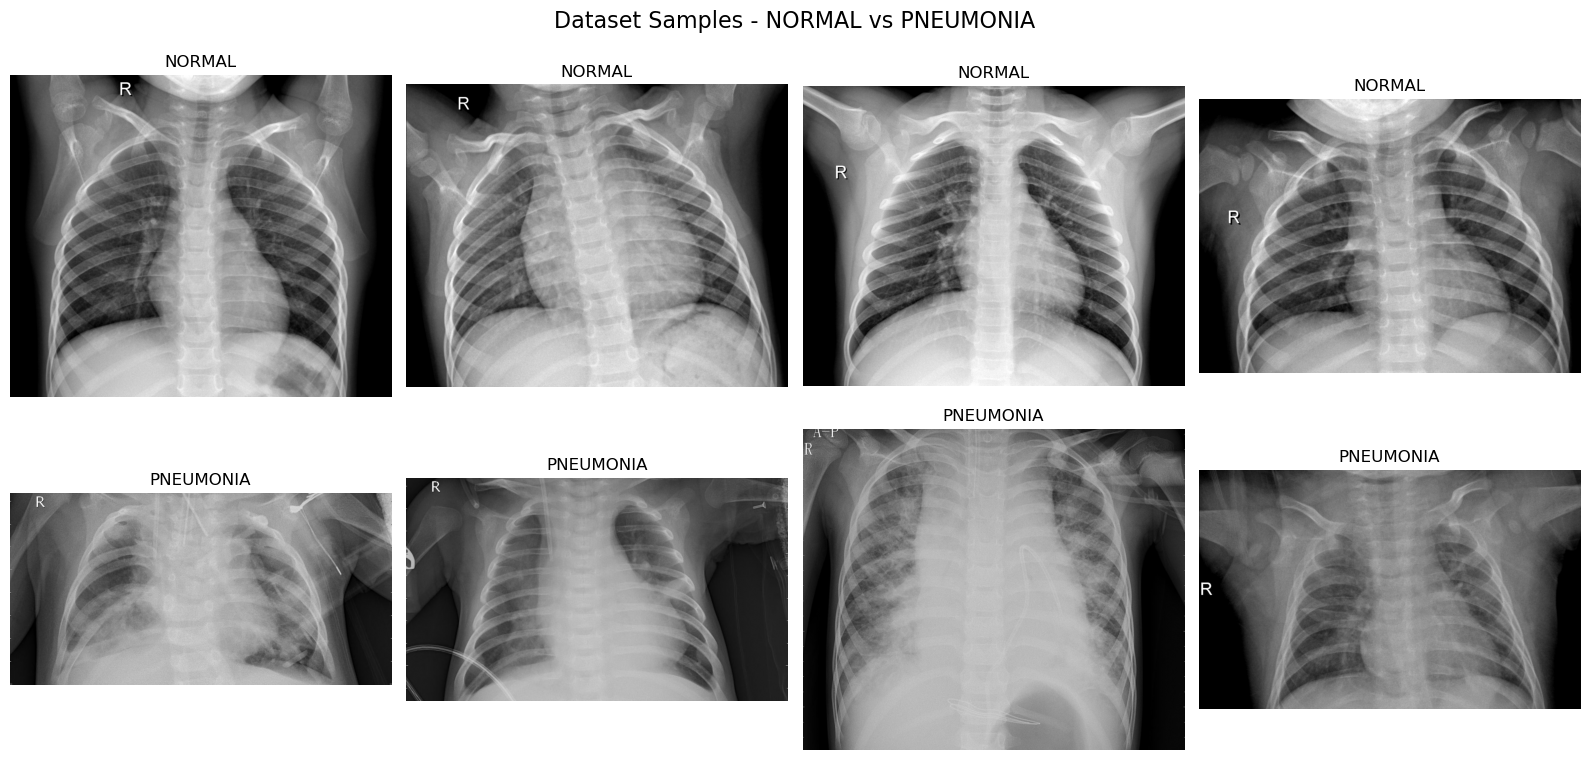

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Dataset Samples - NORMAL vs PNEUMONIA", fontsize=16)

for i, clase in enumerate(["NORMAL", "PNEUMONIA"]):
    path = os.path.join(TRAIN_DIR, clase)
    images = random.sample(os.listdir(path), 4)
    for j, img_name in enumerate(images):
        img = mpimg.imread(os.path.join(path, img_name))
        axes[i, j].imshow(img, cmap="gray")
        axes[i, j].set_title(clase)
        axes[i, j].axis("off")

plt.tight_layout()
plt.savefig("results/dataset_samples.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import cv2
import numpy as np

heights, widths = [], []

for clase in ["NORMAL", "PNEUMONIA"]:
    path = os.path.join(TRAIN_DIR, clase)
    for img_name in os.listdir(path):
        img = cv2.imread(os.path.join(path, img_name))
        if img is not None:
            heights.append(img.shape[0])
            widths.append(img.shape[1])

print(f"Height - min: {min(heights)}, max: {max(heights)}, average: {int(np.mean(heights))}")
print(f"Width - min: {min(widths)}, max: {max(widths)}, average: {int(np.mean(widths))}")

Height  - min: 127, max: 2663, average: 968
Width - min: 384, max: 2916, average: 1320
